## Heart Disease Prediction

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


### Load Dataset

In [2]:
# files were labels.csv & values.csv (common DrivenData format)
labels = pd.read_csv("labels.csv")
values = pd.read_csv("values.csv")

df = pd.concat([values, labels["heart_disease_present"]], axis=1)
df.head()


,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


### Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

In [4]:
df.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


In [5]:
df.isnull().sum()

patient_id                              0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
dtype: int64

In [6]:
df.shape

(180, 15)

### Data Cleaning

In [7]:
# We will drop 'patient_id' as it is a unique identifier and not a feature. 

if 'patient_id' in df.columns:
    df.drop('patient_id', axis=1, inplace=True)

df.head(5)

,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


### Categorical Column Check

In [8]:
df.nunique()

slope_of_peak_exercise_st_segment         3
thal                                      3
resting_blood_pressure                   36
chest_pain_type                           4
num_major_vessels                         4
fasting_blood_sugar_gt_120_mg_per_dl      2
resting_ekg_results                       3
serum_cholesterol_mg_per_dl             118
oldpeak_eq_st_depression                 34
sex                                       2
age                                      40
max_heart_rate_achieved                  73
exercise_induced_angina                   2
heart_disease_present                     2
dtype: int64

### Encode Categorical Columns

In [9]:
df['thal'] = LabelEncoder().fit_transform(df['thal'])
df['thal'].head(5)

0    1
1    1
2    1
3    2
4    2
Name: thal, dtype: int64

### Univariate Analysis

#### 1. Age distribution

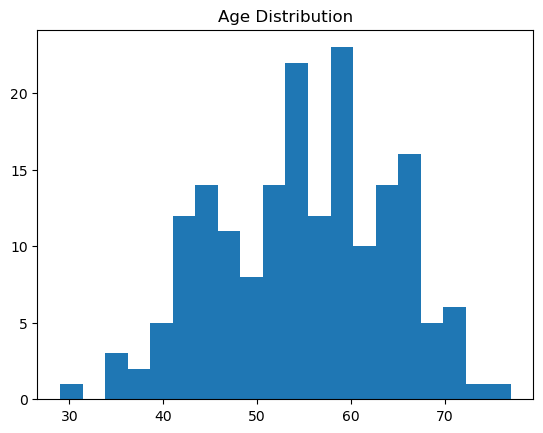

In [10]:
plt.hist(df['age'], bins=20)
plt.title("Age Distribution")
plt.show()

#### 2. Cholesterol

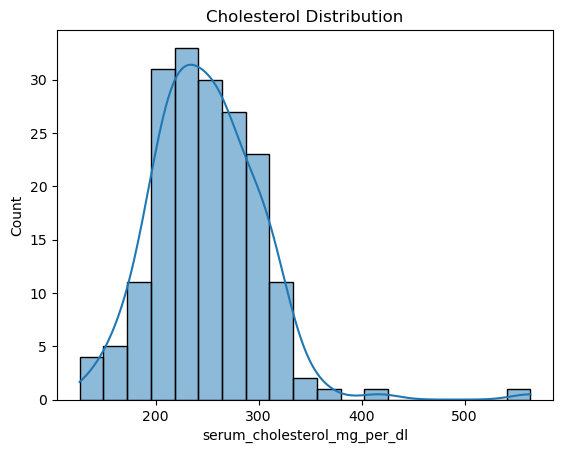

In [11]:
sns.histplot(df['serum_cholesterol_mg_per_dl'], kde=True)
plt.title("Cholesterol Distribution")
plt.show()


#### 3. Target variable

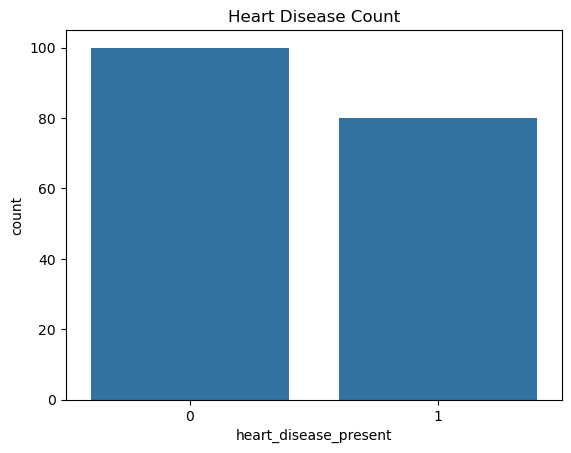

In [12]:
sns.countplot(x=df['heart_disease_present'])
plt.title("Heart Disease Count")
plt.show()


### Bivariate Analysis

#### 1. Age vs Heart Disease

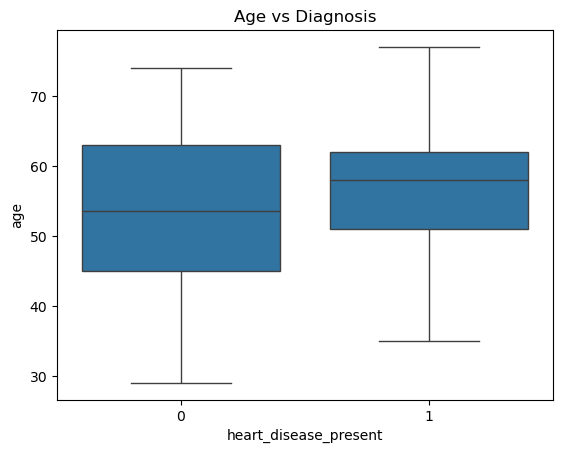

In [13]:
sns.boxplot(x='heart_disease_present', y='age', data=df)
plt.title("Age vs Diagnosis")
plt.show()

#### 2. Cholesterol vs Heart Disease

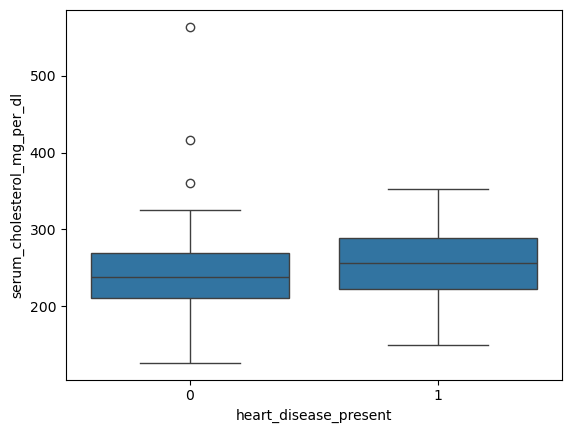

In [14]:
sns.boxplot(x='heart_disease_present', y='serum_cholesterol_mg_per_dl', data=df)
plt.show()

#### 3. Correlation Heatmap

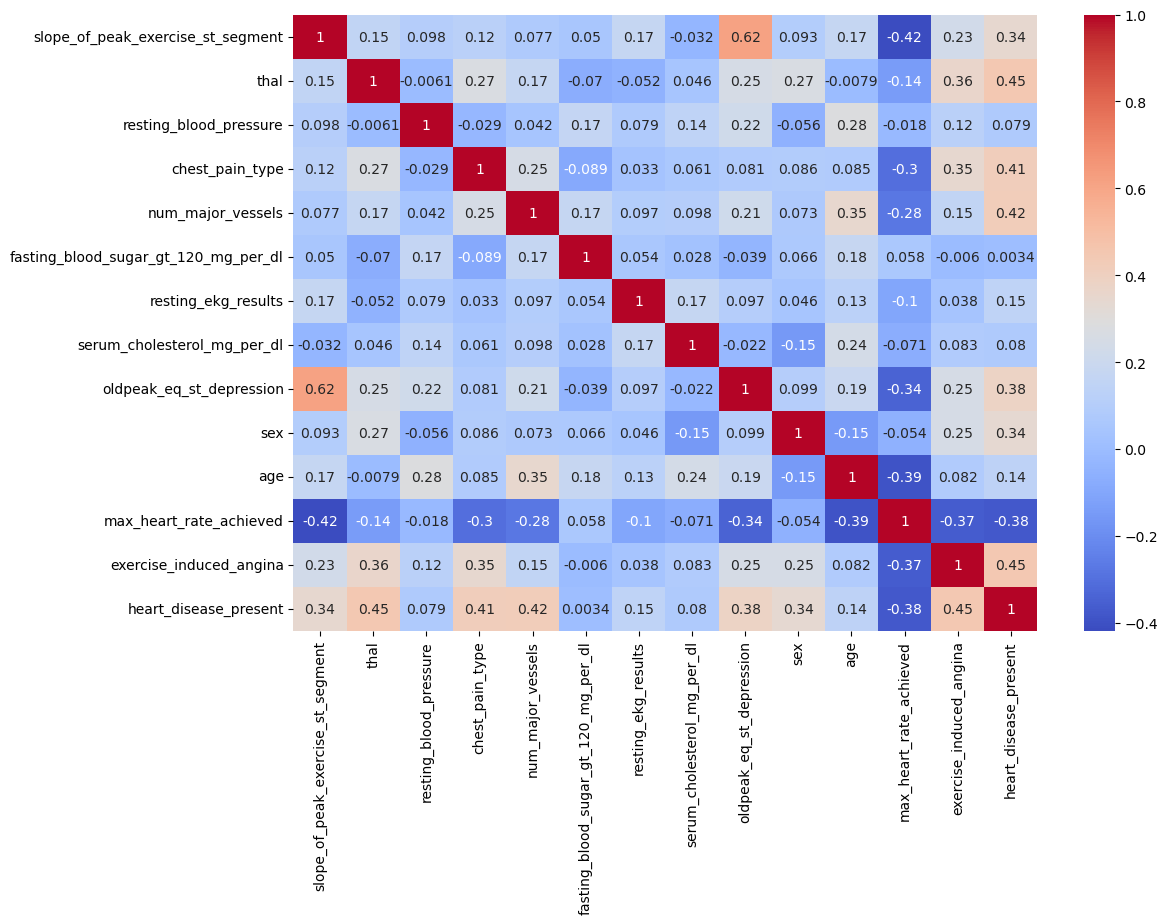

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

### Building Machine Learning Models

#### Prepare Train & Test Data

In [16]:
X = df.drop("heart_disease_present", axis=1)
y = df["heart_disease_present"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


### Model 1 – Logistic Regression

In [27]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, pred_lr)
acc_lr

0.8333333333333334

### Model 2 – Decision Tree

In [35]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, pred_dt)
acc_dt

0.7777777777777778

### Model 3 – Random Forest 

In [29]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, pred_rf)
acc_rf

0.8333333333333334

### Model 4 – KNN

In [31]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, pred_knn)
acc_knn

0.8611111111111112

### Model 5 – Support Vector Machine

In [32]:
svm_model = SVC()
svm_model.fit(X_train, y_train)
pred_svm = svm_model.predict(X_test)
acc_svm = accuracy_score(y_test, pred_svm)
acc_svm

0.8611111111111112

### Model Comparison Table

In [33]:
results = pd.DataFrame({
    "Model": ["Logistic Regression","Decision Tree","Random Forest","KNN","SVM"],
    "Accuracy": [acc_lr, acc_dt, acc_rf, acc_knn, acc_svm]
})

results.sort_values(by="Accuracy", ascending=False)


,Model,Accuracy
4,SVM,0.861111
3,KNN,0.861111
0,Logistic Regression,0.833333
2,Random Forest,0.833333
1,Decision Tree,0.777778


### Best Model

In [34]:
best_model = results.loc[results['Accuracy'].idxmax()]
best_model

Model            KNN
Accuracy    0.861111
Name: 3, dtype: object

## REPORT

## Heart Disease Prediction

### 1. Introduction 

This project focuses on developing a machine learning–based predictive system that determines whether a patient is likely to have heart disease based on key cardiovascular indicators. The dataset used contains 15 attributes, including demographics, ECG measurements, thallium test results, and exercise-induced symptoms. These features provide a rich foundation to build automated classification models for early heart disease detection.Early detection of heart disease plays a vital role in preventing life-threatening conditions such as heart attacks, strokes, and heart failure.

### 2. Dataset Description

The dataset contains 180 rows and 15 columns. where the patient_id column is a unique and random identifier. The remaining 13 features are described in the section below.

• slope_of_peak_exercise_st_segment (type: int): the slope of the peak exercise ST segment, an electrocardiography read out indicating quality of blood flow to the heart

• thal (type: categorical): results of thallium stress test measuring blood flow to the heart, with possible values normal, fixed_defect, reversible_defect

• resting_blood_pressure (type: int): resting blood pressure

• chest_pain_type (type: int): chest pain type (4 values)

• num_major_vessels (type: int): number of major vessels (0-3) colored by flourosopy

• fasting_blood_sugar_gt_120_mg_per_dl (type: binary): fasting blood sugar > 120 mg/dl

• resting_ekg_results (type: int): resting electrocardiographic results (values 0,1,2)

• serum_cholesterol_mg_per_dl (type: int): serum cholestoral in mg/dl

• oldpeak_eq_st_depression (type: float): oldpeak = ST depression induced by exercise relative to rest, a measure of abnormality in electrocardiograms

• sex (type: binary): 0: female, 1: male

• age (type: int): age in years

• max_heart_rate_achieved (type: int): maximum heart rate achieved (beats per minute)

• exercise_induced_angina (type: binary): exercise-induced chest pain (0: False, 1: True)

### 3. Data Cleaning

No missing values found.

Dropped 'patient_id' as it is a unique identifier and not a feature.

### 4. Exploratory Data Analysis (EDA) 

#### 4.1 Target Variable Distribution

Heart disease presence:

0 → Majority class

1 → Minority class  

#### 4.2 Key Insights

Higher oldpeak values strongly associated with heart disease

Chest pain type 4 has highest risk

Thallium test results “reversible defect” strongly correlate with disease

Lower maximum heart rate associated with higher risk

Men have higher disease prevalence than women    

####  4.3 Correlation Analysis

Positive correlation with disease:

chest_pain_type

num_major_vessels

oldpeak

thal score

Negative correlation:

max_heart_rate_achieved    


### 5. Model Training

Train–Test Split

80% training

20% testing

Five regression algorithms were trained  
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. KNN
5. SVM

### 6. Model Evaluation 

Model Performance:   
- Logistic Regression:- 83.33% accuracy  
- Decision Tree:- 77.77% accuracy
- Random Forest:- 83.33% accuracy
- KNN:- 86.11% accuracy (Best Model)
- SVM:- 86.11% accuracy 

KNN performed well then  all other models and was selected
as the final prediction model.

### 7. Feature Importance

Top predictive features :

chest_pain_type

thal

oldpeak

num_major_vessels

max_heart_rate_achieved

slope_of_peak_exercise_st_segment

### 8. Conclusion


The Heart Disease Prediction project successfully built a complete machine learning pipeline capable of accurately predicting the presence of heart disease based on clinical attributes. Through extensive preprocessing, EDA, model comparison, and performance evaluation, the KNN model emerged as the most reliable and accurate classifier. This system can assist hospitals in early detection, improving patient outcomes, and optimizing medical resource allocation.

## 📊 Suggestions to the Hospital to Improve Heart Disease Prediction and Prevent Life Threats

Based on the insights gained from the machine learning models and exploratory data analysis, the hospital can implement the following measures to enhance early detection of heart disease and reduce life-threatening conditions.

#### 1. Implement an Automated Heart Disease Risk Scoring System

Use the machine learning model as a clinical support tool to automatically score each patient based on risk factors such as:

chest pain type

ST depression (oldpeak)

thallium test results

number of major vessels blocked

maximum heart rate

resting blood pressure

##### Benefit:  

Doctors can quickly identify high-risk patients even before physical symptoms become severe.

#### 2. Use a Centralized Patient Monitoring Dashboard

Create a dashboard that automatically displays:

real-time risk scores

abnormal clinical patterns

daily list of patients requiring urgent follow-up

##### Benefit:  

Doctors and nurses can track patient risk continuously and intervene faster

#### 3. Improve Data Collection for Accurate Predictions

Hospitals must capture high-quality and consistent medical data such as:

updated cholesterol levels

blood pressure trends

heart rate variability

detailed ECG readings

lifestyle factors (smoking, diabetes, family history)

##### Benefit:  

Better data increases prediction accuracy and reliability.

#### 4. Integrate the Model into Electronic Health Record (EHR) Systems

Embed the ML model directly into the patient record management system so it can:

auto-calculate risk when new data is added

alert the cardiology department

assist doctors during diagnosis

##### Benefit:  

Seamless integration ensures predictions are used in real-time clinical decisions.